Within this notebook I want to record and explore some of the analysis and findings that I have discovered within my data.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from database import get_connection

load_dotenv()
connection = get_connection()

query = """
SELECT
    p.period_from,
    p.period_to,
    nr.reading_id,
    nr.forecast_intensity,
    nr.actual_intensity
FROM national_readings nr
JOIN period_id p
    ON nr.reading_id = p.id
ORDER BY p.period_from;
"""

national = pd.read_sql(query, connection)
national["period_from"] = pd.to_datetime(national["period_from"])
national["period_to"] = pd.to_datetime(national["period_to"])


national.head()





C:\Users\timro\AppData\Local\Temp\ipykernel_28444\322661294.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  national = pd.read_sql(query, connection)


,period_from,period_to,reading_id,forecast_intensity,actual_intensity
0,2026-08-17 16:30:00+00:00,2026-08-17 17:00:00+00:00,1,192,200.0
1,2026-08-17 18:30:00+00:00,2026-08-17 19:00:00+00:00,3,213,215.0
2,2026-08-17 19:00:00+00:00,2026-08-17 19:30:00+00:00,9,215,215.0
3,2026-08-17 19:30:00+00:00,2026-08-17 20:00:00+00:00,11,212,210.0
4,2026-08-17 20:00:00+00:00,2026-08-17 20:30:00+00:00,13,210,210.0


This is just a first look at the difference in forecast intensity and actual intensity present within the database. As can be seen from this small sample there are times when the forecast and actual intensity match, yet there are also times when they differ. This shows that the forecast intensity is not always accurate and that there is room for improvement in it.

C:\Users\timro\AppData\Local\Temp\ipykernel_28444\2704412770.py:21: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\timro\OneDrive\Documents\uni\non-uni-coding\data project\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


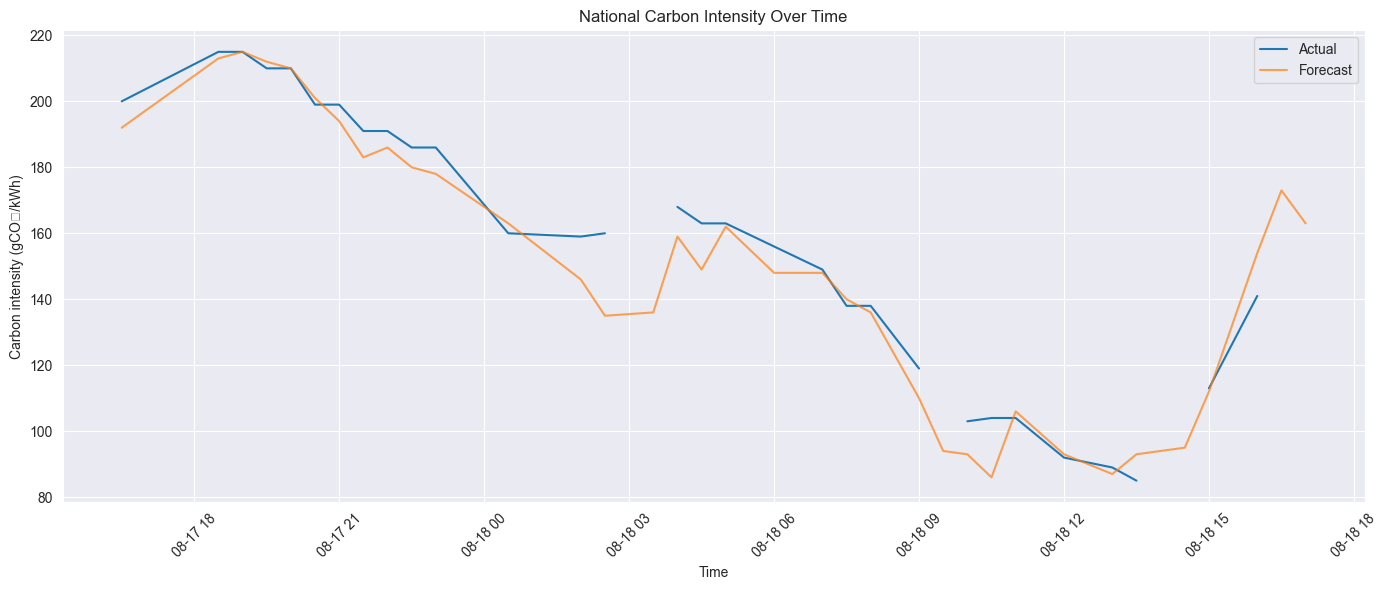

In [13]:
plt.figure(figsize=(14, 6))

plt.plot(
    national["period_from"],
    national["actual_intensity"],
    label="Actual"
)

plt.plot(
    national["period_from"],
    national["forecast_intensity"],
    label="Forecast",
    alpha=0.7
)

plt.xlabel("Time")
plt.ylabel("Carbon intensity (gCO₂/kWh)")
plt.title("National Carbon Intensity Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

This graph has been created to note the spread of carbon intensity with its actual value compared to its predicted. You can see here that although there are time when the actual and predicted values are the same, most of the time there is a small difference between the two. As well as there being period where an actual value was not recorded. This shows that there is room for improvement when it comes to the prediction model being used.

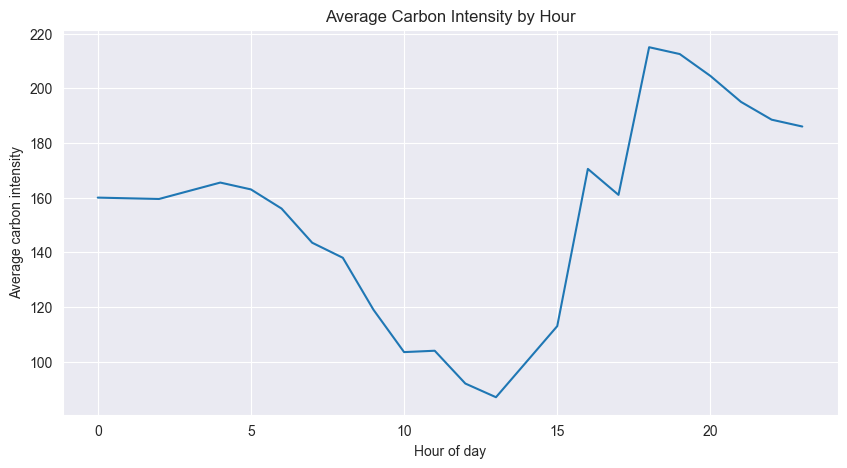

In [14]:
national["hour"] = national["period_from"].dt.hour
hourly = (
    national
    .groupby("hour")["actual_intensity"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly,
    x="hour",
    y="actual_intensity"
)

plt.xlabel("Hour of day")
plt.ylabel("Average carbon intensity")
plt.title("Average Carbon Intensity by Hour")
plt.show()

This graph shows that carbon intensity is lower during the daylight hours of the day and increases as the day goes on. This aligns with what would be expected as there are many factors that lead to electricity generation increasing during the later hours of the day such as lack of daylight or more people being home. So as such this leads to a higher carbon intensity later in the day.